In [1]:
# import packages that are needed to exctract data from the pc and run statistical analysis
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.api as sms
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
import bids
warnings.filterwarnings("ignore")

import sys, importlib
print("Python executable:", sys.executable)
print("fsspec installed:", importlib.util.find_spec("fsspec") is not None)
%pip install fsspec

# Set up the environment
os.environ["ROOTDIR"] = r'D://'   # seth path
rootdir = os.environ["ROOTDIR"]
options = {}
workdir = os.environ["ROOTDIR"]
firstleveldir  = os.path.join(workdir,"BIDS","derivatives","first_level_results")
secondleveldir = os.path.join(workdir,"second_level_results")
demographic = os.path.join(workdir,"metadata")
# output = os.path.join(workdir,)
participants = []

print('firstlevel: ', firstleveldir)

Python executable: c:\Users\angel\Documents\masters-uploaded-github\INPD-neuroimage-cape\.venv-CAPE-neuroimag\Scripts\python.exe
fsspec installed: True
Note: you may need to restart the kernel to use updated packages.
firstlevel:  D://BIDS\derivatives\first_level_results


In [2]:
bidslayout = bids.BIDSLayout(firstleveldir, validate = False) #With validate = True it doesn't find any subjects

if not participants:
    participants = bidslayout.get_subjects() #take all subjects
    #participants_sub = ["sub-" + item for item in participants]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

tmap_allsubj = [] #initialize array for tmaps

print("Loading tmaps for all participants...")
for p in participants:
    #print(f"Subject: {p}")
    p = p.replace("sub-", "")

    # for ses in bidslayout.get_sessions(subject=p):
    #     #print(f"Session: {ses}")                
    
    ses = '1'

    for r in bidslayout.get_runs(subject=p, session=ses):
        #print(f"Run: {r}")

        tmap_metadata = {
            'task': 'rest',
            'suffix': 'tstat',
            'extension': '.txt',
            'run': str(r),
            'session': str(ses),
            'subject': 'sub-'+p,
            'space': 'MNI152NLin2009cAsym',
            'seed': 'SeedtoROI'
        }

        # Save each tmap as a nifti file
        filepath = os.path.join(firstleveldir,tmap_metadata["subject"],"ses-"+tmap_metadata['session'],"func")
        filename = tmap_metadata["subject"] + "_" + \
                    "ses-"+tmap_metadata['session'] + "_" + \
                    "task-"+tmap_metadata['task'] + "_" + \
                    "run-"+tmap_metadata['run'] + "_" + \
                    "space-"+tmap_metadata['space'] + "_" + \
                    "seed-"+tmap_metadata['seed'] + "_" + \
                    tmap_metadata["suffix"] + \
                    tmap_metadata["extension"]
        tmap_path = os.path.join(filepath, filename)

        #load the tmaps for each subject and then append to the tmap_allsubj array
        tmap = pd.read_csv(tmap_path, delimiter=' ', header=None, skiprows=1) #also skips the first row
        tmap.columns = seednames
        tmap_allsubj.append(tmap)

#load socioeconomic and psichometric data for all subjects
print("Loading socioeconomic and psichometric data for all participants...")
socio_psi=pd.read_csv(os.path.join(demographic,'variaveis_analise_conf_nova-exclusão.tsv'), sep='\t')
#substitute in age colunm , to . for decimals
socio_psi['age'] = socio_psi['age'].str.replace(',', '.').astype(float)

# organinzing the tmaps. Joining the columns of the tmaps for all subjects. So for each subject
# we have to join the first collunm of the first tmap with the first column of the second tmap and so on
# and then join the second column of the first tmap with the second column of the second tmap and so on
# and so on
print("Organizing tmaps...")
tmap_allsubj = pd.concat(tmap_allsubj, axis=1)
tmap_allsubj_organized = {}

for seed in seednames:
    #drop columns with names different from seednames[i]
    tmap_allsubj_organized[seed] = tmap_allsubj.drop(columns=[col for col in tmap_allsubj.columns if col != seed])

# What do we have now: tmap_allsubj_organized is a dictionary with keys being the seednames and values being
# dataframes with the tmaps for all subjects for that seed. This have dimensions of n_ROIs x n_subjects
# Now we have to transpose it to get the data in the format n_subjects x n_ROIs and then join with the
# socioeconomic and psichometric data
# Also, we have to add the sub_id column to the conectivity data to be able to join with the socioeconomic
# and psichometric data
subs = {'sub_id': []}
for p in participants:
    ses = '1'
    if bidslayout.get_runs(subject=p, session=ses) != []:
        subs['sub_id'].append('sub-'+p)

subs = pd.DataFrame(subs)

# create the collunms names for the data frame of rois
roi_names = [f'roi_{i}' for i in range(101)]

for seed in seednames:
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].transpose()
    tmap_allsubj_organized[seed].columns = roi_names
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].reset_index().join(subs, how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['index'])

# Now we have to join the tmaps with the socioeconomic and psichometric data
print("Joining tmaps with socioeconomic and psichometric data...")

for seed in seednames:
    tmap_allsubj_organized[seed] = pd.merge(tmap_allsubj_organized[seed], socio_psi, on='sub_id', how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['Unnamed: 0'])

Loading tmaps for all participants...
Loading socioeconomic and psichometric data for all participants...
Organizing tmaps...
Joining tmaps with socioeconomic and psichometric data...


Loading second level results...
Testing linear regression assumptions...


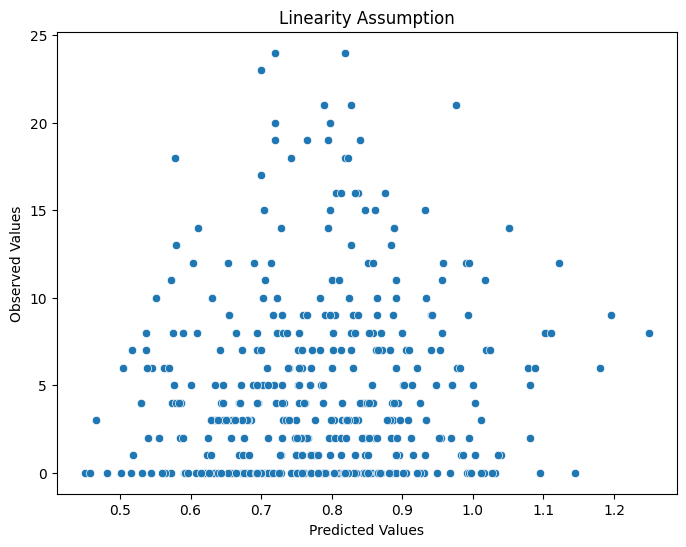

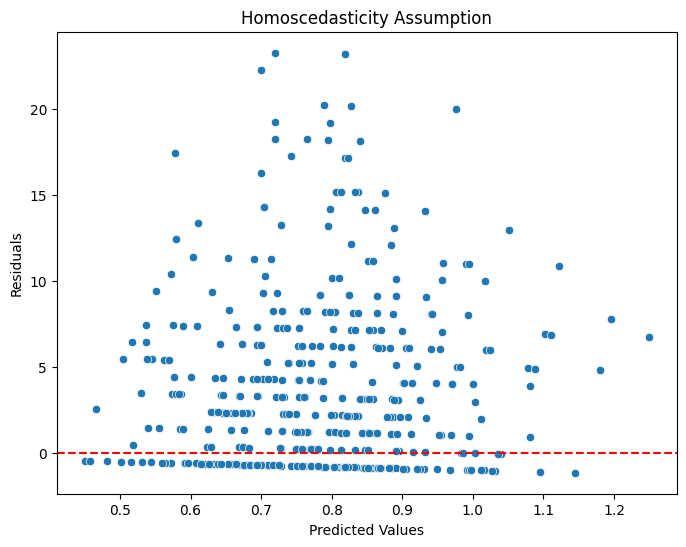

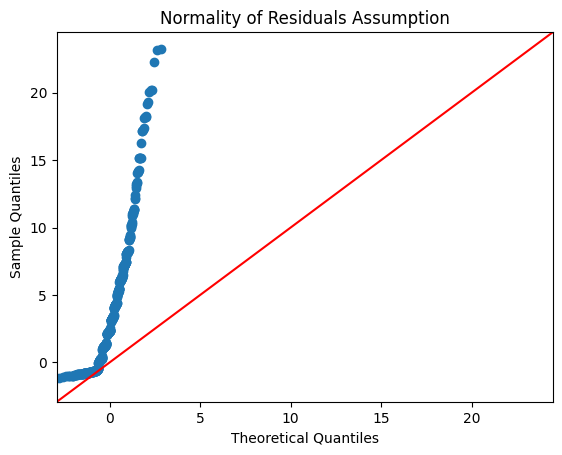

Durbin-Watson statistic: 0.9955707940752607
Positive autocorrelation of residuals


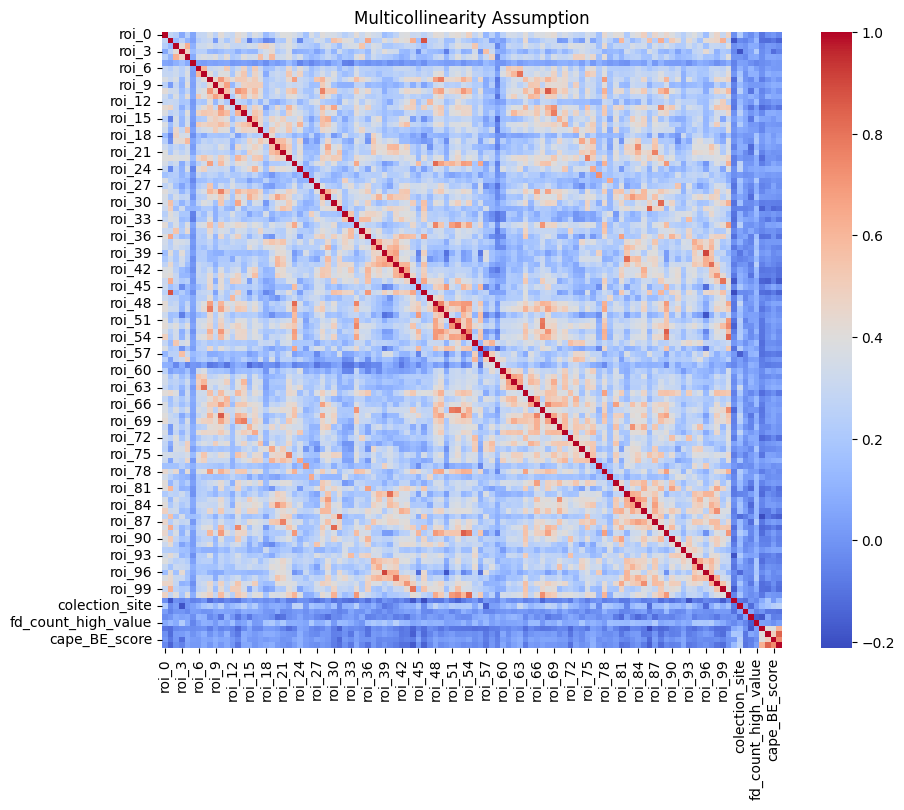

Linear regression assumptions tested.


In [ ]:
# read second level results 
print("Loading second level results...")
sencondlvl = pd.read_csv(os.path.join(secondleveldir,'cape_tot-DRPutamen-roi_24_2ndlvl.csv'))
sencondlvl.drop(columns=['Unnamed: 0'], inplace=True)

predicted = sencondlvl.at[0,'coef']*tmap_allsubj_organized['DRPutamen']['roi_24']+sencondlvl.at[0,'intercept']
observed = tmap_allsubj_organized['DRPutamen']['cape_tot']

#test linear regression assumptions
print("Testing linear regression assumptions...")
# 1. Linearity
plt.figure(figsize=(8,6))
sns.scatterplot(x=predicted, y=observed)
plt.xlabel('Predicted Values')
plt.ylabel('Observed Values')
plt.title('Linearity Assumption')
plt.show()
# 2. Homoscedasticity
residuals = observed - predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=predicted, y=residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Assumption')
plt.axhline(0, color='red', linestyle='--')
plt.show()
# 3. Normality of Residuals
sm.qqplot(residuals, line ='45')
plt.title('Normality of Residuals Assumption')
plt.show()
# 4. Independence of Residuals
dw = sms.durbin_watson(residuals)
print(f'Durbin-Watson statistic: {dw}')
if dw < 1.5:
    print("Positive autocorrelation of residuals")
elif dw > 2.5:
    print("Negative autocorrelation of residuals")
else:
    print("No autocorrelation of residuals")
# 5. No Multicollinearity
correlation_matrix = tmap_allsubj_organized['DRPutamen']['gender', 'collection_site'].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Multicollinearity Assumption')
plt.show()
# Conclusion
print("Linear regression assumptions tested.")

In [5]:
tmap_allsubj_organized['DRPutamen']

,roi_0,roi_1,roi_2,roi_3,roi_4,roi_5,roi_6,roi_7,roi_8,roi_9,...,sub_id,gender,colection_site,abepscore,age,fd_count_high_value,cape_PA_score,cape_PI_score,cape_BE_score,cape_tot
0,5.887719,1.326967,1.113874,0.079695,0.757187,0.004437,1.408916,1.100120,0.963387,-0.184245,...,sub-00003,2,1,10,8.361396,3,0,1,0,1
1,7.740149,2.876397,1.143595,1.225424,1.202197,0.003427,2.820130,2.810660,2.146725,2.118611,...,sub-00015,2,1,19,12.221766,3,0,4,0,5
2,2.264678,2.796078,5.109094,-0.060302,0.089925,-0.013957,3.691757,5.367732,2.452702,-0.419635,...,sub-00019,2,1,13,11.049966,17,0,2,0,4
3,4.835089,1.380862,5.442606,1.922328,6.351242,-0.013267,3.821496,5.347940,5.542401,4.559090,...,sub-00022,2,1,12,13.475702,1,0,3,0,6
4,7.653895,2.756567,-0.549890,3.985198,-0.622493,0.004867,0.478620,0.900414,5.653765,1.348696,...,sub-00028,1,1,16,7.556468,6,0,1,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,7.815303,1.089912,4.072838,2.375206,3.120246,-0.056601,1.886337,5.086645,1.615037,0.714823,...,sub-02494,2,2,18,7.225188,3,0,2,0,3
408,6.756696,3.099056,4.768328,2.788674,7.514076,-0.020647,4.303986,5.795603,7.643997,5.792854,...,sub-02496,1,2,17,8.038330,21,2,5,3,12
409,3.205644,1.141228,1.928106,-0.577648,2.128252,0.431947,-0.150083,-0.410161,1.880355,3.256964,...,sub-02502,1,2,23,9.911020,16,0,2,0,6
410,4.427570,2.548846,1.911801,-1.365596,0.704980,0.002315,0.907845,2.254957,4.160458,2.913595,...,sub-02507,1,2,19,8.440794,8,0,1,1,4
